# Locating the backdoor inside the network

Notebook 01 measured *that* the clean and backdoor latent distributions differ.
This one asks *where the backdoor lives* and whether the thing we found is
actually the mechanism, rather than a correlate of it.

The distinction matters. Every statistic in notebook 01 is **observational**: it
looks at representations and reports a difference. A difference can be a symptom.
The test that separates a symptom from a cause is **intervention**: take the
direction we claim carries the backdoor, add it to a clean image's activations,
and see whether the model produces the attacker's target class. If it does, the
direction is not merely correlated with the backdoor, it is sufficient to trigger
it.

That experiment is the centre of this notebook.

## The quantities

**Trigger Activated Change**, per residual dimension:

$$\text{TAC}_k = \frac{1}{|D|}\sum_{x \in D}
\left| f_k(x_{\text{trigger}}) - f_k(x) \right|$$

**Backdoor direction**, the mean paired difference:

$$r_l = \frac{1}{|\text{pairs}|}\sum_{\text{pairs}}
\left( f_l(x_{\text{trigger}}) - f_l(x) \right)$$

| symbol | meaning |
|---|---|
| $f_l(x)$ | the residual-stream feature of image $x$ at layer $l$ |
| $x_{\text{trigger}}$ | the same image with the trigger applied |
| $k$ | one residual dimension |
| $r_l$ | the direction the trigger writes into at layer $l$ |

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import logging

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from psbd.analysis.cases import load_latent_case
from psbd.analysis.cka import debiased_linear_cka, layerwise_cka_matrix
from psbd.analysis.direction import (
    backdoor_direction,
    make_steering_hook,
    outlier_dimensions,
    project_onto_direction,
    trigger_activated_change,
)
from psbd.analysis.lipschitz import alignment_outlier_score, head_weight_alignment
from psbd.models import network_core

BACKDOORED = "vit_cifar100_badnet_a2o_0_01"
BENIGN = "vit_cifar100_benign"
SAMPLES = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
case = load_latent_case(BACKDOORED, samples=SAMPLES)
print(
    f"{case.folder}: {case.attack}, target class {case.target_label}, layers {case.layers[0]} to {case.layers[-1]}"
)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


vit_cifar100_badnet_a2o_0_01: badnet_a2o, target class 0, layers 0 to 12


## Where the trigger is written

The direction norm rises with depth. The layer where it peaks is where the trigger
has most fully taken over the representation.

In [3]:
directions = {
    layer: backdoor_direction(case.clean_features[layer], case.backdoor_features[layer])
    for layer in case.layers
}
tac = {
    layer: trigger_activated_change(
        case.clean_features[layer], case.backdoor_features[layer]
    )
    for layer in case.layers
}

profile = pd.DataFrame(
    [
        {
            "layer": layer,
            "direction_norm": directions[layer].norm().item(),
            "max_tac": tac[layer].max().item(),
            "mean_tac": tac[layer].mean().item(),
            "outlier_dimensions": len(outlier_dimensions(tac[layer], sensitivity=3.0)),
        }
        for layer in case.layers
    ]
).set_index("layer")
profile.round(4)

,direction_norm,max_tac,mean_tac,outlier_dimensions
layer,,,,
0,0.0000,0.0000,0.0000,0
1,0.0291,0.0088,0.0010,20
2,0.1089,0.0153,0.0030,16
3,0.2188,0.0338,0.0059,20
4,0.5124,0.0934,0.0136,16
5,0.6542,0.1096,0.0179,17
6,1.4235,0.2595,0.0387,11
7,3.8879,0.6876,0.1138,8
8,4.9818,0.6622,0.1648,10


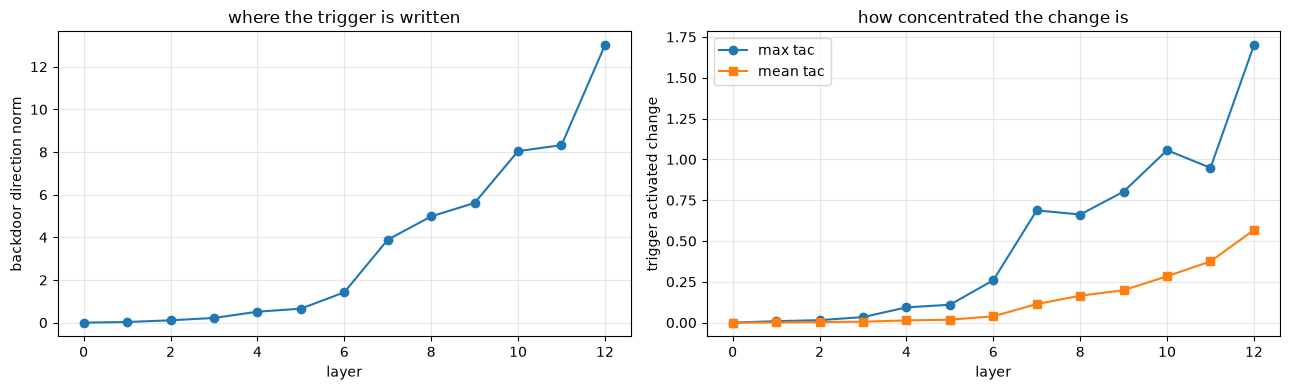

peak layer: 12


In [4]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(profile.index, profile["direction_norm"], marker="o")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("backdoor direction norm")
axes[0].set_title("where the trigger is written")
axes[1].plot(profile.index, profile["max_tac"], marker="o", label="max tac")
axes[1].plot(profile.index, profile["mean_tac"], marker="s", label="mean tac")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("trigger activated change")
axes[1].legend()
axes[1].set_title("how concentrated the change is")
for axis in axes:
    axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

peak_layer = int(profile["direction_norm"].idxmax())
print("peak layer:", peak_layer)

## Is the backdoor a small set of dimensions, or spread out?

If a handful of residual dimensions carried the backdoor, removing them would be a
cheap defence. The TAC spectrum at the peak layer answers whether that is
plausible.

50% of total tac is carried by the top 291 of 768 dimensions
90% of total tac is carried by the top 651 of 768 dimensions


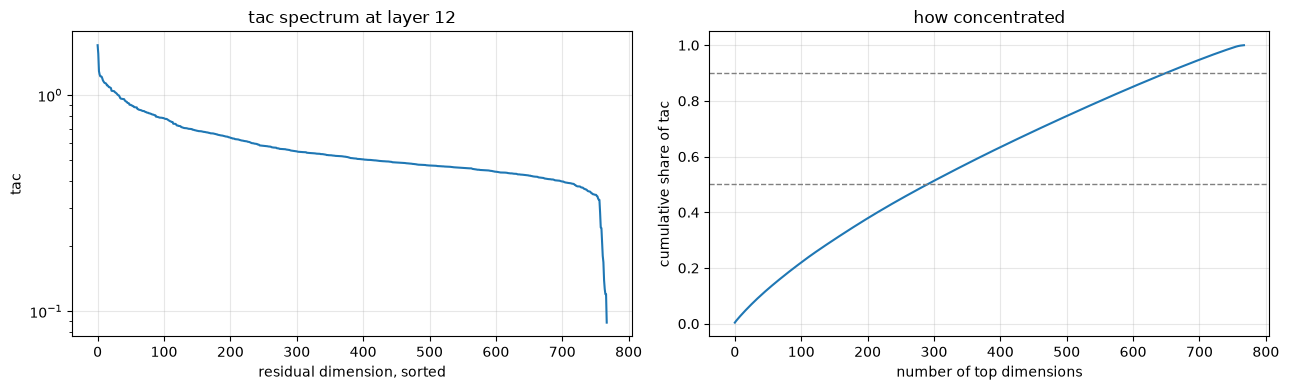

In [5]:
peak_tac = tac[peak_layer]
sorted_tac = peak_tac.sort(descending=True).values
cumulative = sorted_tac.cumsum(0) / sorted_tac.sum()

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sorted_tac.numpy())
axes[0].set_xlabel("residual dimension, sorted")
axes[0].set_ylabel("tac")
axes[0].set_yscale("log")
axes[0].set_title(f"tac spectrum at layer {peak_layer}")
axes[1].plot(cumulative.numpy())
for fraction in (0.5, 0.9):
    reached = int((cumulative >= fraction).nonzero()[0, 0]) + 1
    axes[1].axhline(fraction, ls="--", lw=1, c="grey")
    print(
        f"{fraction:.0%} of total tac is carried by the top {reached} of {len(peak_tac)} dimensions"
    )
axes[1].set_xlabel("number of top dimensions")
axes[1].set_ylabel("cumulative share of tac")
axes[1].set_title("how concentrated")
for axis in axes:
    axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

## The intervention

Everything above is observational. This is the causal test.

Take the backdoor direction at the peak layer, add it to the residual stream of a
**clean** batch during a forward pass, and read the predictions. If the direction
is what carries the backdoor, clean images should start being classified as the
attacker's target class, with no trigger present in the pixels at all.

The scale is swept because the direction is a mean, not a calibrated magnitude.

In [6]:
from torch.utils.data import DataLoader

from psbd.attacks import build_attack, default_config
from psbd.analysis.latent import build_paired_loaders
from psbd.config import DATASET_REGISTRY
from psbd.models import load_checkpoint

CHECKPOINT = f"checkpoints/{BACKDOORED}/attack_result.pt"
spec = DATASET_REGISTRY[case.dataset]
attack = build_attack(
    case.attack, default_config(case.attack), spec.image_size, case.target_label
)
clean_loader, backdoor_loader = build_paired_loaders(
    case.dataset, attack, "raw_data", 64, SAMPLES, seed=0
)
model = load_checkpoint(case.architecture, CHECKPOINT, device)
blocks = list(network_core(model).encoder.layers)


@torch.inference_mode()
def predictions(loader, hook=None, block_index=None):
    handle = (
        blocks[block_index].register_forward_hook(hook) if hook is not None else None
    )
    try:
        predicted = []
        for images, _ in loader:
            predicted.append(model(images.to(device)).argmax(dim=1).cpu())
    finally:
        if handle is not None:
            handle.remove()
    return torch.cat(predicted)


clean_predictions = predictions(clean_loader)
backdoor_predictions = predictions(backdoor_loader)
print(
    f"clean images predicted as target class {case.target_label}: "
    f"{(clean_predictions == case.target_label).float().mean():.4f}"
)
print(
    f"triggered images predicted as target class:                "
    f"{(backdoor_predictions == case.target_label).float().mean():.4f}"
)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


clean images predicted as target class 0: 0.0080
triggered images predicted as target class:                1.0000


In [7]:
# The hook adds the direction to the output of the block that produces layer
# peak_layer, which is block index peak_layer - 1 in 0-indexed terms.
steer_block = peak_layer - 1
direction = directions[peak_layer]

steer_rows = []
for scale in (0.0, 0.5, 1.0, 2.0, 4.0, 8.0):
    hook = make_steering_hook(direction.to(device), scale=scale)
    steered = predictions(clean_loader, hook=hook, block_index=steer_block)
    steer_rows.append(
        {
            "scale": scale,
            "predicted_target": (steered == case.target_label).float().mean().item(),
            "unchanged_from_clean": (steered == clean_predictions)
            .float()
            .mean()
            .item(),
        }
    )

steering = pd.DataFrame(steer_rows).set_index("scale")
steering.round(4)

,predicted_target,unchanged_from_clean
scale,,
0.0,0.008,1.000
0.5,0.066,0.929
1.0,0.427,0.580
2.0,1.000,0.008
4.0,1.000,0.008
8.0,1.000,0.008


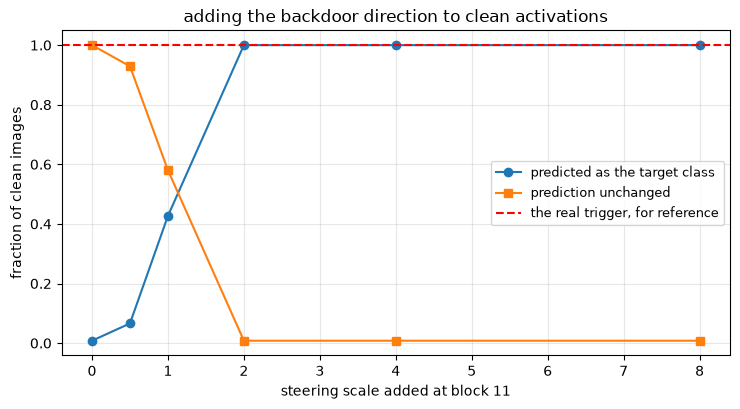

In [8]:
figure, axis = plt.subplots(figsize=(7.5, 4.2))
axis.plot(
    steering.index,
    steering["predicted_target"],
    marker="o",
    label="predicted as the target class",
)
axis.plot(
    steering.index,
    steering["unchanged_from_clean"],
    marker="s",
    label="prediction unchanged",
)
axis.axhline(
    (backdoor_predictions == case.target_label).float().mean().item(),
    ls="--",
    lw=1.5,
    c="red",
    label="the real trigger, for reference",
)
axis.set_xlabel(f"steering scale added at block {steer_block}")
axis.set_ylabel("fraction of clean images")
axis.set_title("adding the backdoor direction to clean activations")
axis.legend(fontsize=9)
axis.grid(alpha=0.3)
figure.tight_layout()
plt.show()

Read the gap between the solid line and the dashed one. If steering reaches the
dashed line, the direction alone reproduces the attack, and the linear account of
the backdoor is complete at this layer. If it climbs but falls short, the direction
is a real part of the mechanism but not all of it, and the shortfall is the part
that is not a single linear direction.

The second curve is the control. A steering vector large enough to destroy the
representation would also push predictions to *some* class, so a rise in target
predictions only means something while the other predictions are still intact.

## Does the same direction work on a model that never learned the trigger?

The negative control for the intervention. A benign model has no
trigger-to-target path, so its own paired difference should not steer anything to
class 0 in particular.

In [9]:
benign_case = load_latent_case(
    BENIGN,
    samples=SAMPLES,
    probe_attack=case.attack,
    probe_target_label=case.target_label,
)
benign_model = load_checkpoint(
    benign_case.architecture, f"checkpoints/{BENIGN}/attack_result.pt", device
)
benign_blocks = list(network_core(benign_model).encoder.layers)
benign_direction = backdoor_direction(
    benign_case.clean_features[peak_layer], benign_case.backdoor_features[peak_layer]
)


@torch.inference_mode()
def benign_predictions(hook=None):
    handle = benign_blocks[steer_block].register_forward_hook(hook) if hook else None
    try:
        return torch.cat(
            [
                benign_model(images.to(device)).argmax(dim=1).cpu()
                for images, _ in clean_loader
            ]
        )
    finally:
        if handle is not None:
            handle.remove()


benign_base = benign_predictions()
benign_rows = [
    {
        "scale": scale,
        "predicted_target": (
            benign_predictions(make_steering_hook(benign_direction.to(device), scale))
            == case.target_label
        )
        .float()
        .mean()
        .item(),
    }
    for scale in (0.0, 1.0, 4.0, 8.0)
]
pd.DataFrame(benign_rows).set_index("scale").round(4)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


,predicted_target
scale,
0.0,0.007
1.0,0.007
4.0,0.007
8.0,0.007


## Layerwise CKA

A single number per layer pair: how similar is the clean representation at layer
$i$ to the backdoor representation at layer $j$. The diagonal is the
same-layer comparison notebook 01 plotted; the off-diagonal shows whether the
backdoor representation at one depth resembles the clean representation at a
different depth, which is what a shortcut would look like.

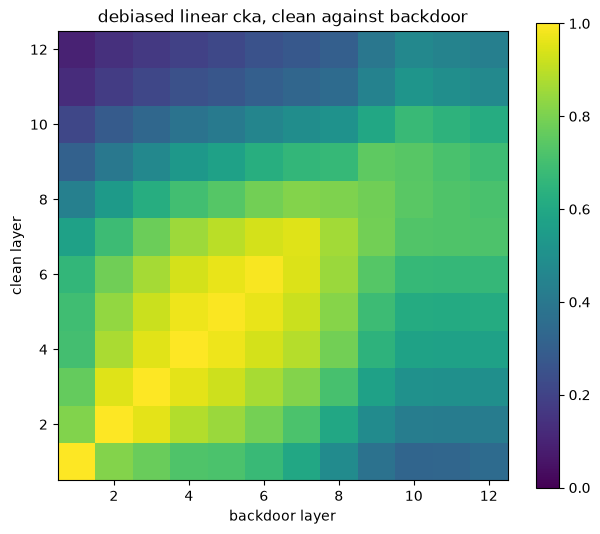

In [10]:
LAYERS_FOR_MATRIX = [layer for layer in case.layers if layer > 0]
matrix = np.array(
    [
        [
            debiased_linear_cka(case.clean_features[i], case.backdoor_features[j])
            for j in LAYERS_FOR_MATRIX
        ]
        for i in LAYERS_FOR_MATRIX
    ]
)

figure, axis = plt.subplots(figsize=(6.4, 5.4))
image = axis.imshow(
    matrix,
    origin="lower",
    vmin=0,
    vmax=1,
    cmap="viridis",
    extent=[
        LAYERS_FOR_MATRIX[0] - 0.5,
        LAYERS_FOR_MATRIX[-1] + 0.5,
        LAYERS_FOR_MATRIX[0] - 0.5,
        LAYERS_FOR_MATRIX[-1] + 0.5,
    ],
)
axis.set_xlabel("backdoor layer")
axis.set_ylabel("clean layer")
axis.set_title("debiased linear cka, clean against backdoor")
figure.colorbar(image, ax=axis)
figure.tight_layout()
plt.show()

## A weights-only detector, for contrast

Everything so far needed data. `head_weight_alignment` needs none: it reads the
classifier head and the early attention output projections and asks whether one
class row is anomalously aligned with an early-layer shortcut.

It is included because a data-free detector is a genuinely different threat model,
and because its behaviour here is informative either way.

In [11]:
alignment_rows = []
for name, folder in (("backdoored", BACKDOORED), ("benign", BENIGN)):
    inspected = load_checkpoint("vit", f"checkpoints/{folder}/attack_result.pt", device)
    counts = head_weight_alignment(inspected, num_layers=3, threshold_quantile=0.99)
    z, top_class = alignment_outlier_score(counts)
    alignment_rows.append(
        {
            "model": name,
            "z": z,
            "top_class": top_class,
            "is_the_attack_target": top_class == case.target_label,
            "flagged_at_z_above_3": z > 3,
        }
    )
pd.DataFrame(alignment_rows).round(4)

,model,z,top_class,is_the_attack_target,flagged_at_z_above_3
0,backdoored,0.4624,7,False,False
1,benign,0.3664,64,False,False


A detector that flags the benign model, or that flags the backdoored model while
naming the wrong class, has not detected anything. Both outcomes are reported as
measured.